1. 라이브러리 설정

In [1]:
import os
import json
import glob
import random
import cv2
import matplotlib.pyplot as plt
from collections import Counter

In [25]:
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

2. 데이터 경로 설정

In [2]:
data_path = os.path.join(
    os.getcwd(),
    '..',
    'data',
    'raw',
    'sprint_ai_project1_data'
)

train_image_path = os.path.join(data_path, 'train_images')
train_annotation_path = os.path.join(data_path, 'train_annotations')
test_image_path = os.path.join(data_path, 'test_images')

print('데이터 경로:', data_path)
print('Train 이미지 경로:', train_image_path)
print('Train Annotation 경로:', train_annotation_path)
print('Test 이미지 경로:', test_image_path)

데이터 경로: c:\Users\user\git\pill_detection_ai_14\pill-detection-ai\notebooks\..\data\raw\sprint_ai_project1_data
Train 이미지 경로: c:\Users\user\git\pill_detection_ai_14\pill-detection-ai\notebooks\..\data\raw\sprint_ai_project1_data\train_images
Train Annotation 경로: c:\Users\user\git\pill_detection_ai_14\pill-detection-ai\notebooks\..\data\raw\sprint_ai_project1_data\train_annotations
Test 이미지 경로: c:\Users\user\git\pill_detection_ai_14\pill-detection-ai\notebooks\..\data\raw\sprint_ai_project1_data\test_images


3. 실제 파일 개수 확인

In [3]:
train_images = os.listdir(train_image_path)
train_annotations = os.listdir(train_annotation_path)
test_images = os.listdir(test_image_path)

print('Train 이미지 개수:', len(train_images))
print('Train Annotation 개수:', len(train_annotations)) 
print('Test 이미지 개수:', len(test_images))

Train 이미지 개수: 232
Train Annotation 개수: 114
Test 이미지 개수: 842


In [ ]:
4. 실제 JSON 파일 개수

In [5]:
json_files = glob.glob(os.path.join(train_annotation_path, '**', '*.json'),
                       recursive=True)

print('Train Annotation JSON 파일 개수:', len(json_files))
print('Train Annotation JSON 파일 예시:')

for json_file in json_files[:5]:
    print(json_file)

Train Annotation JSON 파일 개수: 763
Train Annotation JSON 파일 예시:
c:\Users\user\git\pill_detection_ai_14\pill-detection-ai\notebooks\..\data\raw\sprint_ai_project1_data\train_annotations\K-001900-016548-019607-029451_json\K-001900\K-001900-016548-019607-029451_0_2_0_2_70_000_200.json
c:\Users\user\git\pill_detection_ai_14\pill-detection-ai\notebooks\..\data\raw\sprint_ai_project1_data\train_annotations\K-001900-016548-019607-029451_json\K-001900\K-001900-016548-019607-029451_0_2_0_2_75_000_200.json
c:\Users\user\git\pill_detection_ai_14\pill-detection-ai\notebooks\..\data\raw\sprint_ai_project1_data\train_annotations\K-001900-016548-019607-029451_json\K-001900\K-001900-016548-019607-029451_0_2_0_2_90_000_200.json
c:\Users\user\git\pill_detection_ai_14\pill-detection-ai\notebooks\..\data\raw\sprint_ai_project1_data\train_annotations\K-001900-016548-019607-029451_json\K-016548\K-001900-016548-019607-029451_0_2_0_2_70_000_200.json
c:\Users\user\git\pill_detection_ai_14\pill-detection-ai\noteb

5. JSON 파일 구조 확인

In [6]:
with open(json_files[0], 'r', encoding='utf-8') as f:
    annotation_data = json.load(f)

print(annotation_data.keys())

dict_keys(['images', 'type', 'annotations', 'categories'])


In [ ]:
6. images 안에 있는 정보 확인

In [7]:
print("Image 개수 : ", len(annotation_data['images']))
print("첫 번째 Image : ")
print(annotation_data['images'][0])

Image 개수 :  1
첫 번째 Image : 
{'file_name': 'K-001900-016548-019607-029451_0_2_0_2_70_000_200.png', 'width': 976, 'height': 1280, 'imgfile': 'K-001900-016548-019607-029451_0_2_0_2_70_000_200.png', 'drug_N': 'K-001900', 'drug_S': '정상알약', 'back_color': '연회색 배경', 'drug_dir': '앞면', 'light_color': '주백색', 'camera_la': 70, 'camera_lo': 0, 'size': 200, 'dl_idx': '1900', 'dl_mapping_code': 'K-001900', 'dl_name': '보령부스파정 5mg', 'dl_name_en': 'Buspar Tab. 5mg Boryung', 'img_key': 'http://connectdi.com/design/img/drug/1Mxwka5v0lL.jpg', 'dl_material': '부스피론염산염', 'dl_material_en': 'Buspirone Hydrochloride', 'dl_custom_shape': '정제, 저작정', 'dl_company': '보령제약(주)', 'dl_company_en': 'Boryung', 'di_company_mf': '', 'di_company_mf_en': '', 'item_seq': 198700706, 'di_item_permit_date': '19870323', 'di_class_no': '[01170]정신신경용제', 'di_etc_otc_code': '전문의약품', 'di_edi_code': '641901280,A09302381', 'chart': '이약은 양면볼록한 장방형의 흰색정제이다', 'drug_shape': '장방형', 'thick': 2.5, 'leng_long': 8, 'leng_short': 4.5, 'print_front':

In [ ]:
7. annotations 안에 있는 정보 확인

In [8]:
print('Annotation 개수:', len(annotation_data['annotations']))
print('첫 번째 Annotation:')
print(annotation_data['annotations'][0])

Annotation 개수: 1
첫 번째 Annotation:
{'area': 35910, 'iscrowd': 0, 'bbox': [644, 845, 189, 190], 'category_id': 1900, 'ignore': 0, 'segmentation': [], 'id': 133, 'image_id': 34}


8. category_id와 약 이름 매핑 확인

In [12]:
print('Category 개수:', len(annotation_data['categories']))
print('Categories 키:', annotation_data['categories'][0].keys())

for category in annotation_data['categories']:
    print(
        'ID:', category['id'],
        '| 약 이름:', category['name']
    )

Category 개수: 1
Categories 키: dict_keys(['supercategory', 'id', 'name'])
ID: 1900 | 약 이름: 보령부스파정 5mg


In [ ]:
9. 전체 데이터의 클래스 개수 확인

In [15]:
category_counts = Counter()

for json_file in json_files:
    with open(json_file, 'r', encoding='utf-8') as f:
        annotation_data = json.load(f)

    for annotation in annotation_data['annotations']:
        category_counts[annotation['category_id']] += 1

print("전체 클래스 개수 : ", len(category_counts))
print("클래스별 개수 : ")
for category_id, count in category_counts.most_common():
    print(f"  클래스 {category_id}: {count}개")

전체 클래스 개수 :  56
클래스별 개수 : 
  클래스 3351: 153개
  클래스 3483: 45개
  클래스 35206: 37개
  클래스 16262: 23개
  클래스 21325: 22개
  클래스 16232: 21개
  클래스 3832: 20개
  클래스 20238: 20개
  클래스 36637: 19개
  클래스 16548: 18개
  클래스 29667: 18개
  클래스 38162: 18개
  클래스 19232: 17개
  클래스 22074: 16개
  클래스 20014: 16개
  클래스 33880: 16개
  클래스 41768: 16개
  클래스 1900: 15개
  클래스 13900: 15개
  클래스 18147: 15개
  클래스 32310: 14개
  클래스 18357: 13개
  클래스 31863: 12개
  클래스 20877: 12개
  클래스 25469: 12개
  클래스 27733: 12개
  클래스 25367: 12개
  클래스 2483: 9개
  클래스 30308: 9개
  클래스 22347: 9개
  클래스 28763: 9개
  클래스 16688: 8개
  클래스 19607: 6개
  클래스 29345: 6개
  클래스 12778: 6개
  클래스 25438: 6개
  클래스 19861: 6개
  클래스 3544: 6개
  클래스 4543: 5개
  클래스 29451: 3개
  클래스 33009: 3개
  클래스 21771: 3개
  클래스 27926: 3개
  클래스 24850: 3개
  클래스 16551: 3개
  클래스 33208: 3개
  클래스 3743: 3개
  클래스 13395: 3개
  클래스 12081: 3개
  클래스 19552: 3개
  클래스 22362: 3개
  클래스 34597: 3개
  클래스 31885: 3개
  클래스 27777: 3개
  클래스 12247: 3개
  클래스 27993: 3개


In [ ]:
10. 클래스 ID와 약 이름 매핑

In [18]:
category_names = {}
for json_file in json_files:
    with open(json_file, 'r', encoding='utf-8') as f:
        annotation_data = json.load(f)

    for category in annotation_data['categories']:
        category_names[category['id']] = category['name']

for category_id, count in category_counts.most_common():
    print(
        'ID:', category_id,
        '| 약 이름:', category_names[category_id],
        '| 개수:', count
    )

ID: 3351 | 약 이름: 일양하이트린정 2mg | 개수: 153
ID: 3483 | 약 이름: 기넥신에프정(은행엽엑스)(수출용) | 개수: 45
ID: 35206 | 약 이름: 아토젯정 10/40mg | 개수: 37
ID: 16262 | 약 이름: 크레스토정 20mg | 개수: 23
ID: 21325 | 약 이름: 아토르바정 10mg | 개수: 22
ID: 16232 | 약 이름: 리피토정 20mg | 개수: 21
ID: 3832 | 약 이름: 뉴로메드정(옥시라세탐) | 개수: 20
ID: 20238 | 약 이름: 플라빅스정 75mg | 개수: 20
ID: 36637 | 약 이름: 로수젯정10/5밀리그램 | 개수: 19
ID: 16548 | 약 이름: 가바토파정 100mg | 개수: 18
ID: 29667 | 약 이름: 리바로정 4mg | 개수: 18
ID: 38162 | 약 이름: 로수바미브정 10/20mg | 개수: 18
ID: 19232 | 약 이름: 콜리네이트연질캡슐 400mg | 개수: 17
ID: 22074 | 약 이름: 리피로우정 20mg | 개수: 16
ID: 20014 | 약 이름: 마도파정 | 개수: 16
ID: 33880 | 약 이름: 글리틴정(콜린알포세레이트) | 개수: 16
ID: 41768 | 약 이름: 카발린캡슐 25mg | 개수: 16
ID: 1900 | 약 이름: 보령부스파정 5mg | 개수: 15
ID: 13900 | 약 이름: 에빅사정(메만틴염산염)(비매품) | 개수: 15
ID: 18147 | 약 이름: 리리카캡슐 150mg | 개수: 15
ID: 32310 | 약 이름: 글리아타민연질캡슐 | 개수: 14
ID: 18357 | 약 이름: 종근당글리아티린연질캡슐(콜린알포세레이트)  | 개수: 13
ID: 31863 | 약 이름: 아질렉트정(라사길린메실산염) | 개수: 12
ID: 20877 | 약 이름: 엑스포지정 5/160mg | 개수: 12
ID: 25469 | 약 이름: 아모잘탄정 5/100mg | 개수: 12
ID

11. 이미지와 Annotation 연결 확인

In [21]:
missing_images = []

for json_file in json_files[:5]:
    with open(json_file, 'r', encoding='utf-8') as f:
        annotation_data = json.load(f)

    image_name = annotation_data['images'][0]['file_name']
    image_file = os.path.join(train_image_path, image_name)

    if not os.path.exists(image_file):
        missing_images.append(image_name)

print("전체 JSON 개수 :", len(json_files))
print("누락된 이미지 개수 :", len(missing_images))

if missing_images:
    print("\n누락된 이미지 예시:")
    for image_name in missing_images:
        print(image_name)
else:
    print("누락된 이미지가 없습니다.")

전체 JSON 개수 : 763
누락된 이미지 개수 : 0
누락된 이미지가 없습니다.


In [ ]:
12. 이미지, Bounding Box 시각화

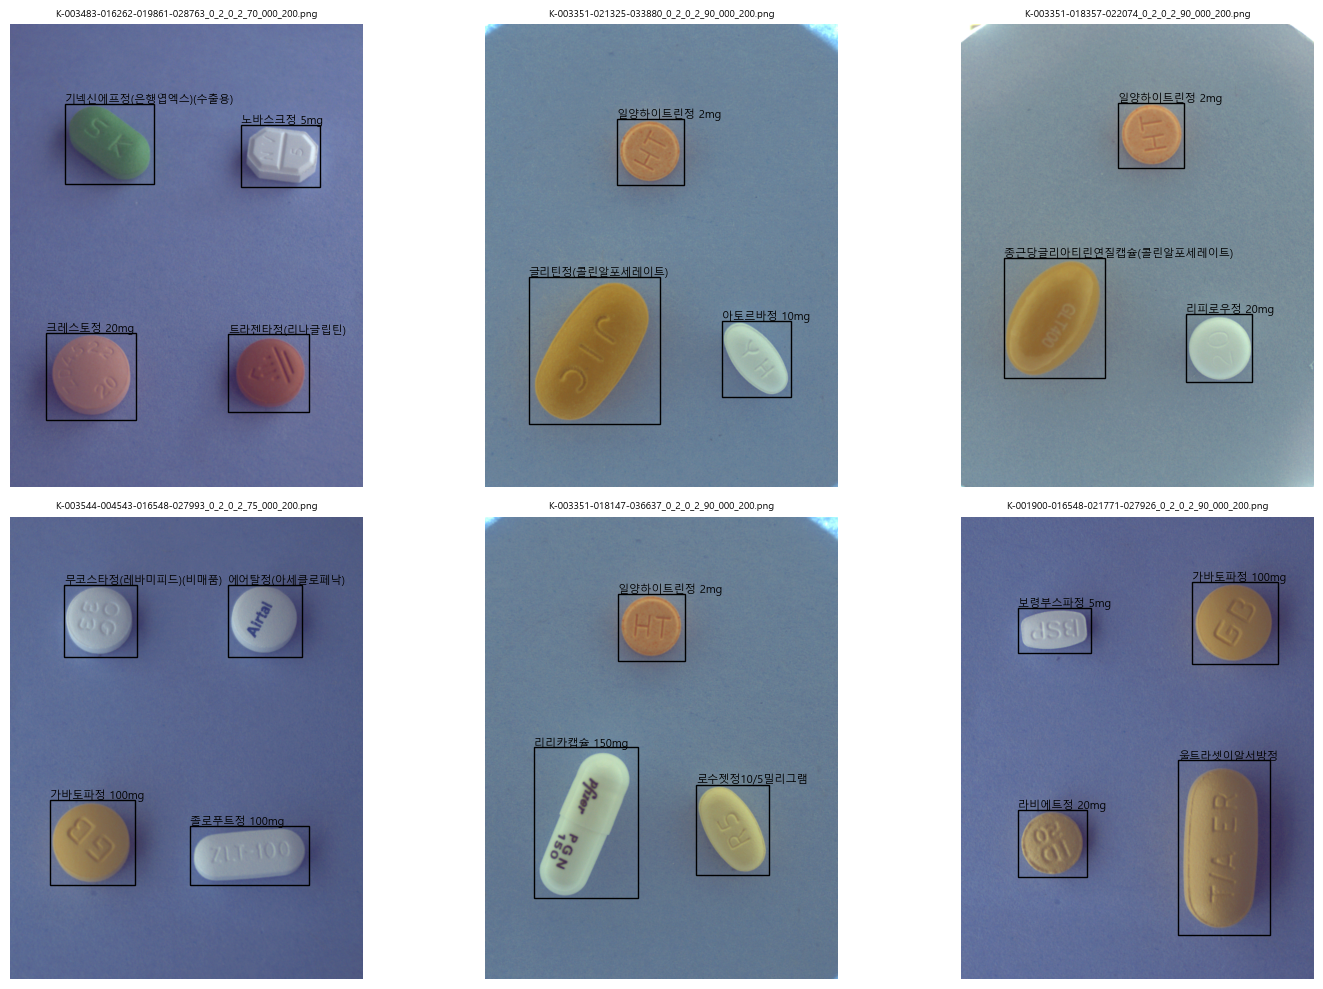

In [33]:
sample_images = random.sample(train_images, 6)

plt.figure(figsize=(15, 10))

for i, image_name in enumerate(sample_images):
    image_file = os.path.join(train_image_path, image_name)

    image = cv2.imread(image_file)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 해당 이미지의 annotation 찾기
    annotations = []

    for json_file in json_files:
        with open(json_file, 'r', encoding='utf-8') as f:
            annotation_data = json.load(f)

        if annotation_data['images'][0]['file_name'] == image_name:
            annotations.extend(annotation_data['annotations'])

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)

    for annotation in annotations:
        x, y, w, h = annotation['bbox']

        rect = plt.Rectangle(
            (x, y),
            w,
            h,
            fill=False
        )

        plt.gca().add_patch(rect)

        plt.text(
            x,
            y - 5,
            category_names[annotation['category_id']],
            fontsize=8
        )

    plt.title(image_name, fontsize=7)
    plt.axis('off')

plt.tight_layout()
plt.show()

13. Bounding Box 크기 분포 확인

In [34]:
bbox_widths = []
bbox_heights = []

for json_file in json_files:
    with open(json_file, 'r', encoding='utf-8') as f:
        annotation_data = json.load(f)

    for annotation in annotation_data['annotations']:
        x, y, w, h = annotation['bbox']

        bbox_widths.append(w)
        bbox_heights.append(h)

print('BBox 개수:', len(bbox_widths))

print('\n가로 크기')
print('최소:', min(bbox_widths))
print('최대:', max(bbox_widths))
print('평균:', sum(bbox_widths) / len(bbox_widths))

print('\n세로 크기')
print('최소:', min(bbox_heights))
print('최대:', max(bbox_heights))
print('평균:', sum(bbox_heights) / len(bbox_heights))

BBox 개수: 763

가로 크기
최소: 125
최대: 529
평균: 250.0078636959371

세로 크기
최소: 126
최대: 664
평균: 265.7640891218873


14. Bounding Box 좌표 유효성 검증

In [35]:
invalid_bboxes = []

for json_file in json_files:
    with open(json_file, 'r', encoding='utf-8') as f:
        annotation_data = json.load(f)

    image_info = annotation_data['images'][0]

    image_name = image_info['file_name']
    image_width = image_info['width']
    image_height = image_info['height']

    for annotation in annotation_data['annotations']:
        x, y, w, h = annotation['bbox']

        # bbox가 이미지 범위를 벗어나는지 확인
        if (
            x < 0 or
            y < 0 or
            x + w > image_width or
            y + h > image_height or
            w <= 0 or
            h <= 0
        ):
            invalid_bboxes.append({
                'image_name': image_name,
                'category_id': annotation['category_id'],
                'bbox': annotation['bbox'],
                'image_size': (image_width, image_height)
            })

print('전체 BBox 개수:', len(bbox_widths))
print('잘못된 BBox 개수:', len(invalid_bboxes))

for item in invalid_bboxes:
    print('\n이미지:', item['image_name'])
    print('클래스:', item['category_id'])
    print('BBox:', item['bbox'])
    print('이미지 크기:', item['image_size'])

전체 BBox 개수: 763
잘못된 BBox 개수: 1

이미지: K-003351-016262-018357_0_2_0_2_75_000_200.png
클래스: 18357
BBox: [6567, 625, 311, 315]
이미지 크기: (976, 1280)


In [ ]:
15. 이미지별 Annotation 개수 분포 확인

In [37]:
annotation_count_distribution = Counter(
    image_annotation_counts.values()
)

print('이미지당 Annotation 개수 분포')

for count, image_count in sorted(annotation_count_distribution.items()):
    print(f'Annotation {count}개인 이미지: {image_count}장')

이미지당 Annotation 개수 분포
Annotation 2개인 이미지: 7장
Annotation 3개인 이미지: 151장
Annotation 4개인 이미지: 74장


한 이미지에 여러 개의 객체가 존재한다. 단순 이미지 분류가 아닌 여러 객체의 위치와 클래스를 동시에 예측하는 객체 탐지(Object Detection) 문제이다.

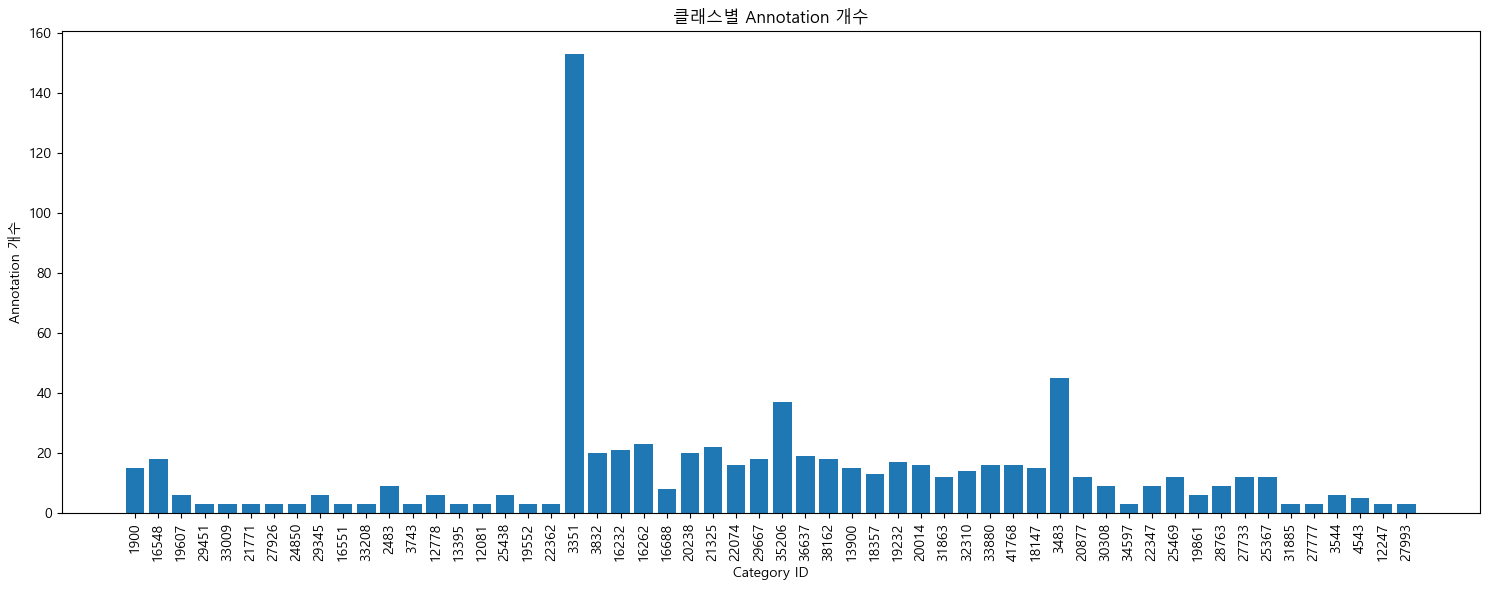

In [38]:
plt.figure(figsize=(15, 6))

plt.bar(
    [str(category_id) for category_id, count in category_counts.items()],
    category_counts.values()
)

plt.xlabel('Category ID')
plt.ylabel('Annotation 개수')
plt.title('클래스별 Annotation 개수')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

16. 이미지 크기 확인

In [39]:
image_sizes = Counter()

for json_file in json_files:
    with open(json_file, 'r', encoding='utf-8') as f:
        annotation_data = json.load(f)

    image_info = annotation_data['images'][0]

    image_sizes[
        (image_info['width'], image_info['height'])
    ] += 1

print('이미지 크기 분포')

for size, count in image_sizes.items():
    print(f'{size}: {count}장')

이미지 크기 분포
(976, 1280): 763장


17. 실제 이미지 파일 크기 확인

In [40]:
actual_image_sizes = Counter()

for image_name in train_images:
    image_file = os.path.join(train_image_path, image_name)

    image = cv2.imread(image_file)

    if image is not None:
        height, width = image.shape[:2]
        actual_image_sizes[(width, height)] += 1

print('실제 이미지 크기 분포')

for size, count in actual_image_sizes.items():
    print(f'{size}: {count}장')

실제 이미지 크기 분포
(976, 1280): 232장


18. 실제 이미지 읽기 오류 확인

In [41]:
invalid_images = []

for image_name in train_images:
    image_file = os.path.join(train_image_path, image_name)

    image = cv2.imread(image_file)

    if image is None:
        invalid_images.append(image_name)

print('전체 이미지:', len(train_images))
print('읽기 실패 이미지:', len(invalid_images))

if invalid_images:
    print('\n읽기 실패 이미지:')
    for image_name in invalid_images:
        print(image_name)
else:
    print('모든 이미지를 정상적으로 읽을 수 있습니다.')

전체 이미지: 232
읽기 실패 이미지: 0
모든 이미지를 정상적으로 읽을 수 있습니다.


19. 이미지 채널 확인

In [42]:
channel_counts = Counter()

for image_name in train_images:
    image_file = os.path.join(train_image_path, image_name)

    image = cv2.imread(image_file)

    if image is not None:
        channel_counts[image.shape[2]] += 1

print('이미지 채널 분포')

for channels, count in channel_counts.items():
    print(f'{channels}채널: {count}장')

이미지 채널 분포
3채널: 232장


20. 이미지 밝기 분포 확인

In [43]:
brightness_values = []

for image_name in train_images:
    image_file = os.path.join(train_image_path, image_name)

    image = cv2.imread(image_file)

    if image is not None:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        brightness_values.append(gray.mean())

print('평균 밝기')
print('최소:', min(brightness_values))
print('최대:', max(brightness_values))
print('평균:', sum(brightness_values) / len(brightness_values))

평균 밝기
최소: 98.55219006147541
최대: 163.59390288806352
평균: 127.65231547164267


21. 밝기 분포 확인

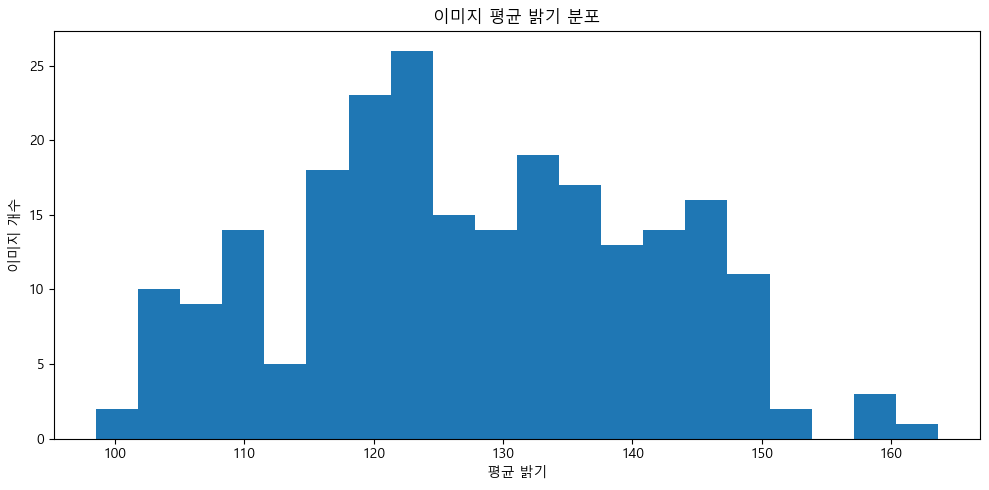

In [44]:
plt.figure(figsize=(10, 5))

plt.hist(brightness_values, bins=20)

plt.xlabel('평균 밝기')
plt.ylabel('이미지 개수')
plt.title('이미지 평균 밝기 분포')

plt.tight_layout()
plt.show()

22. 클래스 별 이미지 개수 확인

In [45]:
class_image_counts = {}

for json_file in json_files:
    with open(json_file, 'r', encoding='utf-8') as f:
        annotation_data = json.load(f)

    image_name = annotation_data['images'][0]['file_name']

    for annotation in annotation_data['annotations']:
        category_id = annotation['category_id']

        if category_id not in class_image_counts:
            class_image_counts[category_id] = set()

        class_image_counts[category_id].add(image_name)

print('클래스별 이미지 개수')

for category_id, images in sorted(
    class_image_counts.items(),
    key=lambda x: len(x[1]),
    reverse=True
):
    print(
        f'ID: {category_id} | '
        f'약 이름: {category_names[category_id]} | '
        f'이미지: {len(images)}장'
    )

클래스별 이미지 개수
ID: 3351 | 약 이름: 일양하이트린정 2mg | 이미지: 153장
ID: 3483 | 약 이름: 기넥신에프정(은행엽엑스)(수출용) | 이미지: 45장
ID: 35206 | 약 이름: 아토젯정 10/40mg | 이미지: 37장
ID: 16262 | 약 이름: 크레스토정 20mg | 이미지: 23장
ID: 21325 | 약 이름: 아토르바정 10mg | 이미지: 22장
ID: 16232 | 약 이름: 리피토정 20mg | 이미지: 21장
ID: 3832 | 약 이름: 뉴로메드정(옥시라세탐) | 이미지: 20장
ID: 20238 | 약 이름: 플라빅스정 75mg | 이미지: 20장
ID: 36637 | 약 이름: 로수젯정10/5밀리그램 | 이미지: 19장
ID: 16548 | 약 이름: 가바토파정 100mg | 이미지: 18장
ID: 29667 | 약 이름: 리바로정 4mg | 이미지: 18장
ID: 38162 | 약 이름: 로수바미브정 10/20mg | 이미지: 18장
ID: 19232 | 약 이름: 콜리네이트연질캡슐 400mg | 이미지: 17장
ID: 22074 | 약 이름: 리피로우정 20mg | 이미지: 16장
ID: 20014 | 약 이름: 마도파정 | 이미지: 16장
ID: 33880 | 약 이름: 글리틴정(콜린알포세레이트) | 이미지: 16장
ID: 41768 | 약 이름: 카발린캡슐 25mg | 이미지: 16장
ID: 1900 | 약 이름: 보령부스파정 5mg | 이미지: 15장
ID: 13900 | 약 이름: 에빅사정(메만틴염산염)(비매품) | 이미지: 15장
ID: 18147 | 약 이름: 리리카캡슐 150mg | 이미지: 15장
ID: 32310 | 약 이름: 글리아타민연질캡슐 | 이미지: 14장
ID: 18357 | 약 이름: 종근당글리아티린연질캡슐(콜린알포세레이트)  | 이미지: 13장
ID: 31863 | 약 이름: 아질렉트정(라사길린메실산염) | 이미지: 12장
ID: 20877 | 약 이름: 엑스포지정 5/

23. Test 이미지 크기 확인

In [46]:
test_image_sizes = Counter()

for image_name in test_images:
    image_file = os.path.join(test_image_path, image_name)

    image = cv2.imread(image_file)

    if image is not None:
        height, width = image.shape[:2]
        test_image_sizes[(width, height)] += 1

print('Test 이미지 크기 분포')

for size, count in test_image_sizes.items():
    print(f'{size}: {count}장')

Test 이미지 크기 분포
(976, 1280): 842장


24. Test 이미지 읽기 오류 확인

In [47]:
invalid_test_images = []

for image_name in test_images:
    image_file = os.path.join(test_image_path, image_name)

    image = cv2.imread(image_file)

    if image is None:
        invalid_test_images.append(image_name)

print('전체 Test 이미지:', len(test_images))
print('읽기 실패 이미지:', len(invalid_test_images))

if invalid_test_images:
    print('\n읽기 실패 이미지:')
    for image_name in invalid_test_images:
        print(image_name)
else:
    print('모든 Test 이미지를 정상적으로 읽을 수 있습니다.')

전체 Test 이미지: 842
읽기 실패 이미지: 0
모든 Test 이미지를 정상적으로 읽을 수 있습니다.


25. EDA 최종 요약

In [50]:
print('EDA 최종 요약')

print(f'Train 이미지: {len(train_images)}장')
print(f'Test 이미지: {len(test_images)}장')
print(f'Train Annotation: {len(json_files)}개')
print(f'클래스 수: {len(category_counts)}개')

print('\n[이미지 크기]')
for size, count in actual_image_sizes.items():
    print(f'Train {size}: {count}장')

for size, count in test_image_sizes.items():
    print(f'Test {size}: {count}장')

print('\n[이미지당 Annotation]')
for count, image_count in sorted(annotation_count_distribution.items()):
    print(f'Annotation {count}개: {image_count}장')

print('\n[BBox 크기]')
print(f'가로 평균: {sum(bbox_widths) / len(bbox_widths):.2f}')
print(f'세로 평균: {sum(bbox_heights) / len(bbox_heights):.2f}')

print('\n[BBox 유효성]')
print(f'잘못된 BBox: {len(invalid_bboxes)}개')

print('\n[이미지 읽기 오류]')
print(f'Train 읽기 실패: {len(invalid_images)}장')
print(f'Test 읽기 실패: {len(invalid_test_images)}장')

print('\n[채널]')
for channels, count in channel_counts.items():
    print(f'{channels}채널: {count}장')

EDA 최종 요약
Train 이미지: 232장
Test 이미지: 842장
Train Annotation: 763개
클래스 수: 56개

[이미지 크기]
Train (976, 1280): 232장
Test (976, 1280): 842장

[이미지당 Annotation]
Annotation 2개: 7장
Annotation 3개: 151장
Annotation 4개: 74장

[BBox 크기]
가로 평균: 250.01
세로 평균: 265.76

[BBox 유효성]
잘못된 BBox: 1개

[이미지 읽기 오류]
Train 읽기 실패: 0장
Test 읽기 실패: 0장

[채널]
3채널: 232장


주요 EDA 결과

1. 데이터 규모
Train 232장, Test 842장, Annotation 763개, 56개 클래스

2. 다중 객체 구조
한 이미지에 2~4개의 객체가 존재하며, 대부분 3개의 객체가 포함되어 있어 단순 이미지 분류가 아닌 객체 탐지 문제가 적합하다.

3. 클래스 불균형
클래스별 Annotation 개수가 균일하지 않아 일부 클래스의 데이터 부족 문제가 존재한다.

4. Annotation 이상치
전체 BBox 중 이미지 영역을 벗어나는 잘못된 BBox 1개가 발견되어 전처리 과정에서 처리할 필요가 있다.